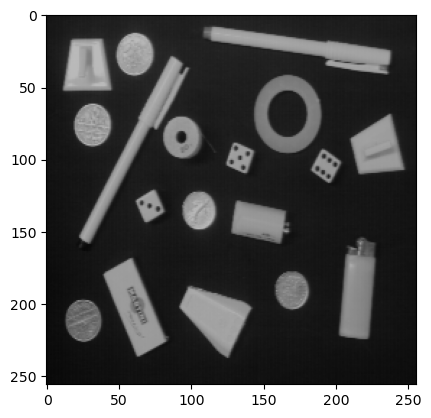

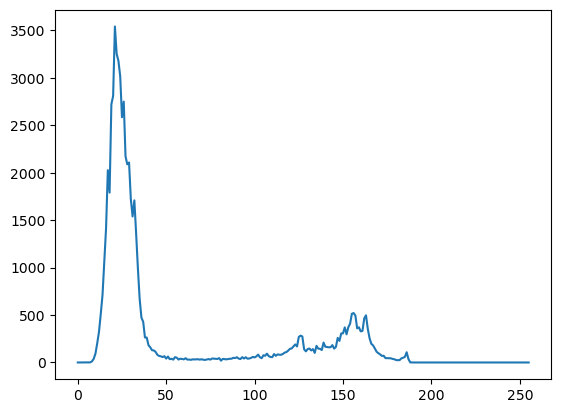

In [202]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image = cv2.imread("images/OBJECTS.png", cv2.IMREAD_GRAYSCALE)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.show()

# Visualizar histograma
hist = cv2.calcHist([image],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

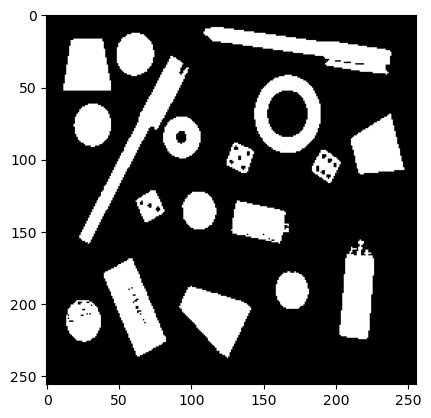

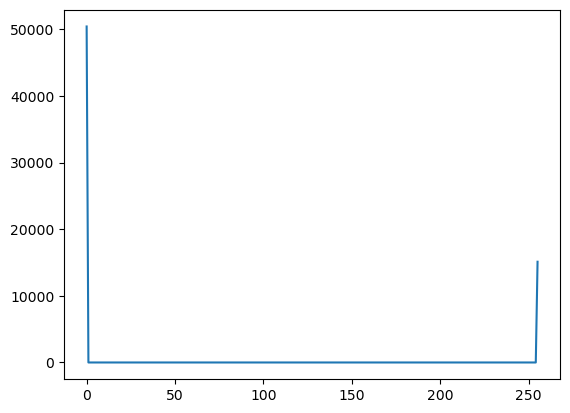

In [203]:
# Aplique el algoritmo de umbralización global

thres_value, thres_image = cv2.threshold(image, 90, 255, cv2.THRESH_BINARY)

# Visualizar imagen
plt.imshow(thres_image, cmap="gray",  vmin=0, vmax=255)
plt.show()

# Visualizar histograma
hist = cv2.calcHist([thres_image],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

84.0


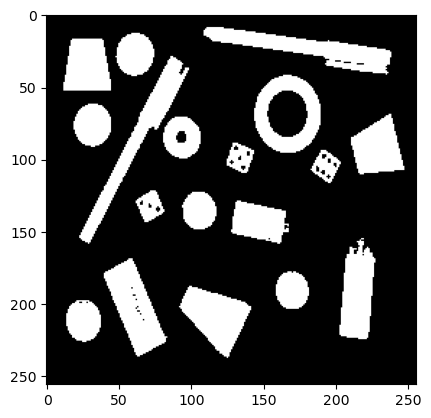

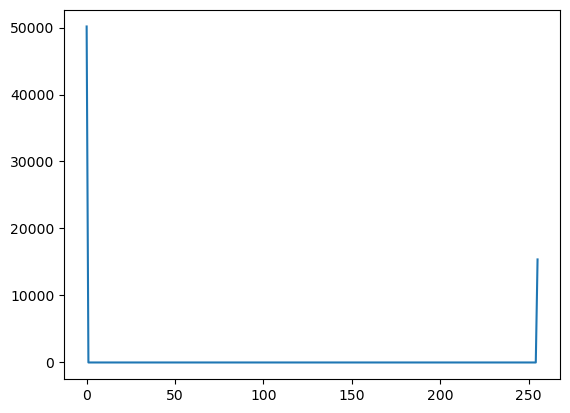

In [204]:
# Aplique el algoritmo de umbralización de Otsu con un solo valor

thres_value, thres_image = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
print(thres_value)

# Visualizar imagen
plt.imshow(thres_image, cmap="gray",  vmin=0, vmax=255)
plt.show()

# Visualizar histograma
hist = cv2.calcHist([thres_image],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

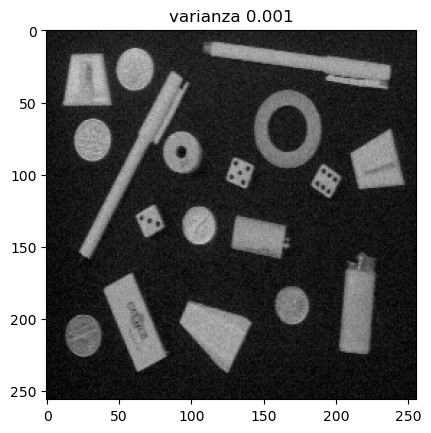

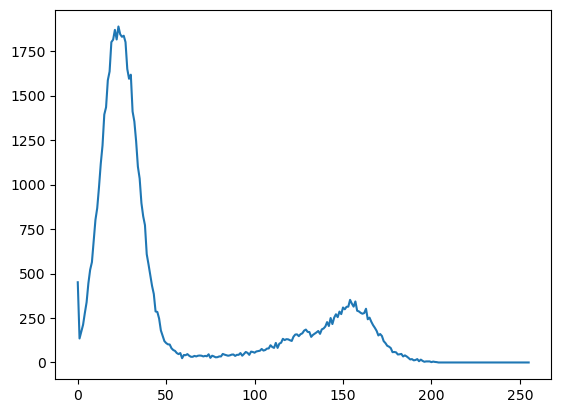

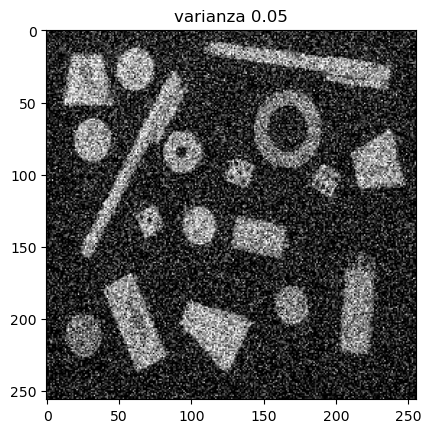

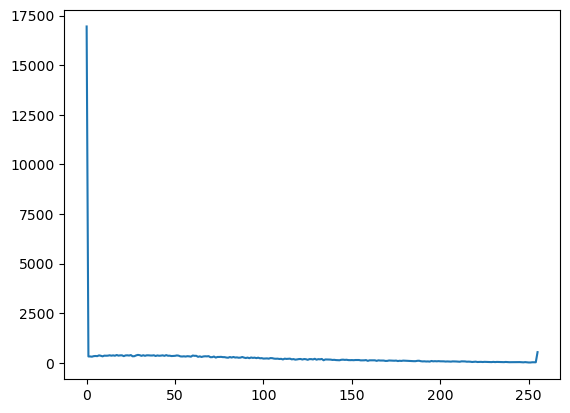

In [205]:
# Ahora introduzca ruido gaussiano aditivo con varianza de 0.001 y luego con varianza de 0.05. Visualice el histograma de la imagen resultante


from skimage.util import random_noise

noised_image = random_noise(image, mode='gaussian', mean=0,  var=0.001)

noised_image = noised_image * 255

noised_image = noised_image.astype(np.uint8)

# Visualizar imagen
plt.imshow(noised_image, cmap="gray",  vmin=0, vmax=255)
plt.title("varianza 0.001")
plt.show()

# Visualizar histograma
hist = cv2.calcHist([noised_image],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

noised_image = random_noise(image, mode='gaussian', mean=0,  var=0.05)

noised_image = noised_image * 255

noised_image = noised_image.astype(np.uint8)

# Visualizar imagen
plt.imshow(noised_image, cmap="gray",  vmin=0, vmax=255)
plt.title("varianza 0.05")
plt.show()

# Visualizar histograma
hist = cv2.calcHist([noised_image],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()


¿Qué sucede? ¿Por qué sucede esto?
Lo que sucede es que al meter ruido gaussiano, se estan generando unas variaciones de una forma distribuida normal. Esto dificulta encontrar regiones, fronteras y la tarea de segmentar se complica aun mas.

84.0


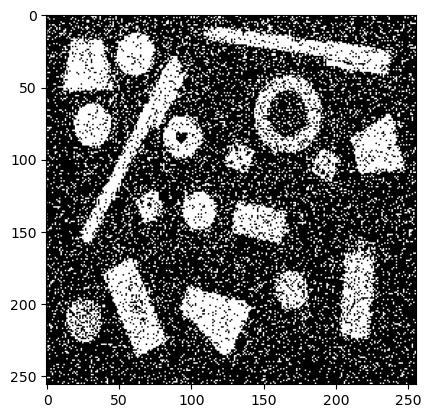

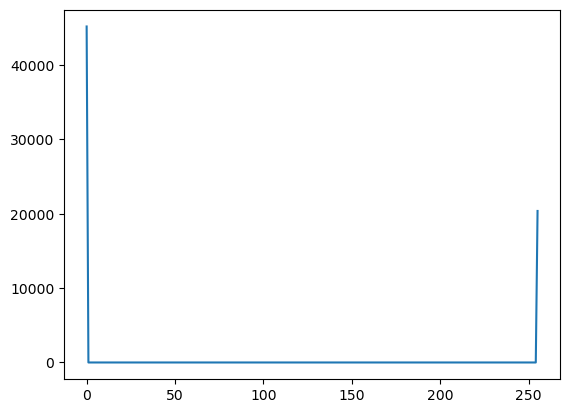

In [206]:
# Vuelva a correr las umbralizaciones sobre la imagen ¿Cómo afecta el ruido al resultado?

thres_value, thres_image = cv2.threshold(noised_image, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
print(thres_value)

# Visualizar imagen
plt.imshow(thres_image, cmap="gray",  vmin=0, vmax=255)
plt.show()

# Visualizar histograma
hist = cv2.calcHist([thres_image],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

¿Cómo afecta el ruido al resultado?
La segmentación ya no es tan precisa como la primera, dentro de los objetos quedaron pixeles negros, culpa del ruido gaussiano.

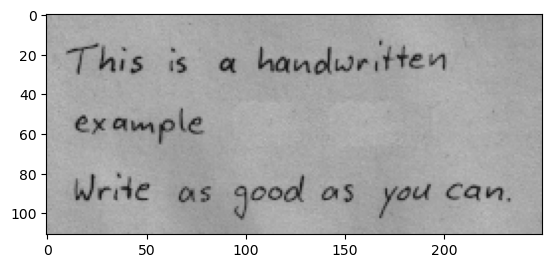

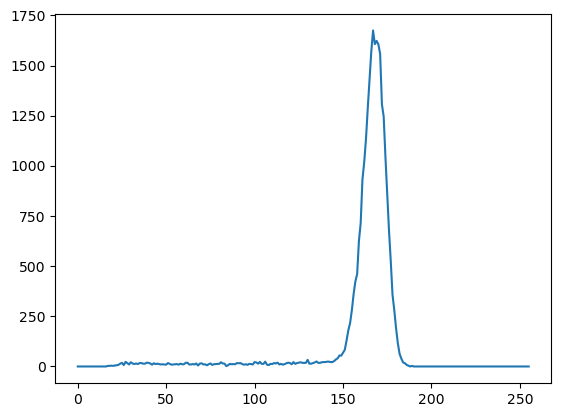

In [207]:
image = cv2.imread("images/Text.png", cv2.IMREAD_GRAYSCALE)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.show()

# Visualizar histograma
hist = cv2.calcHist([image],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

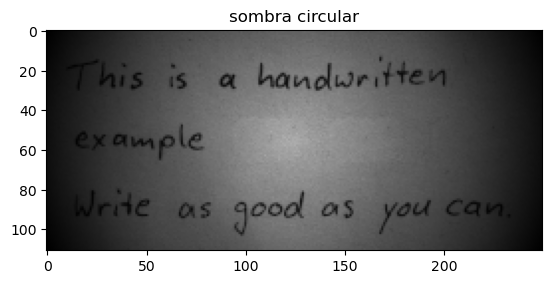

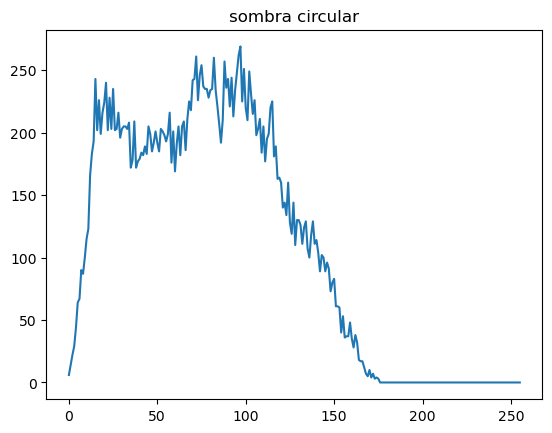

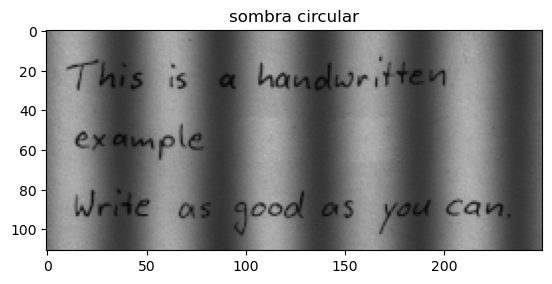

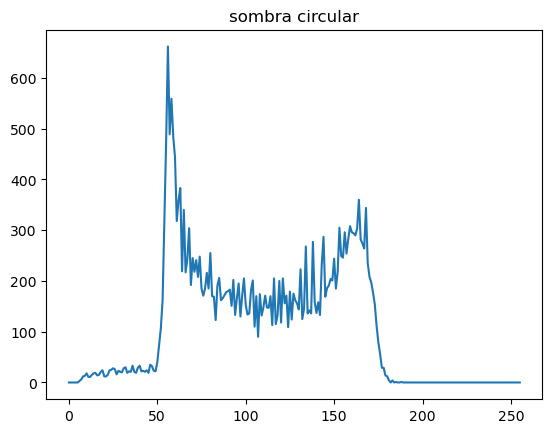

In [208]:
# Introduzca ahora una sombra circular lateral y una sombra sinusoidal en la imagen
# (pruebe con diferentes valores y úselos para los pasos 10 y 11). Visualice el resultado.

# ---------- Sombra circular --------------
import numpy as np

rows, cols = image.shape
x, y = np.meshgrid(np.arange(cols), np.arange(rows))
#Cálculo del centro
cx, cy = cols // 2, rows // 2
#Cálculo del radio y distancia posible
distance = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
max_dist = np.sqrt(cx**2 + cy**2) 

#Aplicación del gradiente
spot_shading = 1 - (distance / max_dist)  
spot_image = image * spot_shading

spot_image = spot_image.astype(np.uint8)

# Visualizar imagen
plt.imshow(spot_image, cmap="gray",  vmin=0, vmax=255)
plt.title("sombra circular")
plt.show()

# Visualizar histograma
hist = cv2.calcHist([spot_image],[0],None,[256],[0,256])
plt.plot(hist)
plt.title("sombra circular")
plt.show()

# ---------- Sombra sinusoidal --------------
# Cantidad de perturbaciones
frequency = 50  
#Intensidad de los picos
amplitude = 0.5

#Cálculo y aplicación del efecto
sinusoidal_shading = (1 + amplitude * np.sin(2 * np.pi * x / frequency)) / 1.5
sinusoidal_image = image * sinusoidal_shading

sinusoidal_image = sinusoidal_image.astype(np.uint8)

# Visualizar imagen
plt.imshow(sinusoidal_image, cmap="gray",  vmin=0, vmax=255)
plt.title("sombra circular")
plt.show()

# Visualizar histograma
hist = cv2.calcHist([sinusoidal_image],[0],None,[256],[0,256])
plt.plot(hist)
plt.title("sombra circular")
plt.show()

117.0


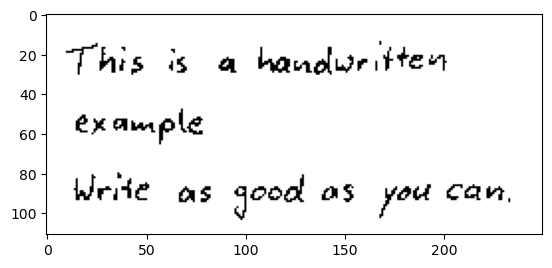

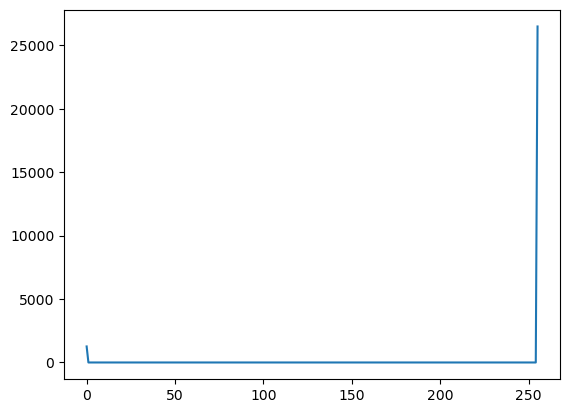

75.0


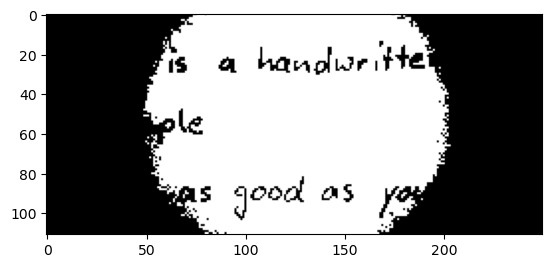

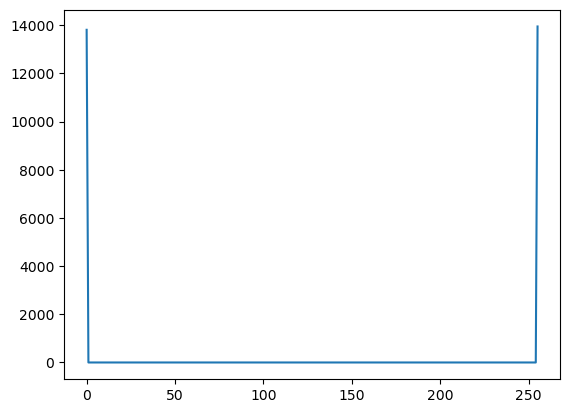

55.0


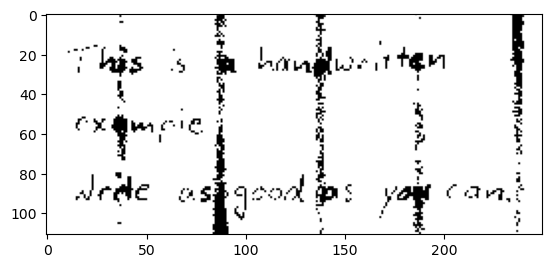

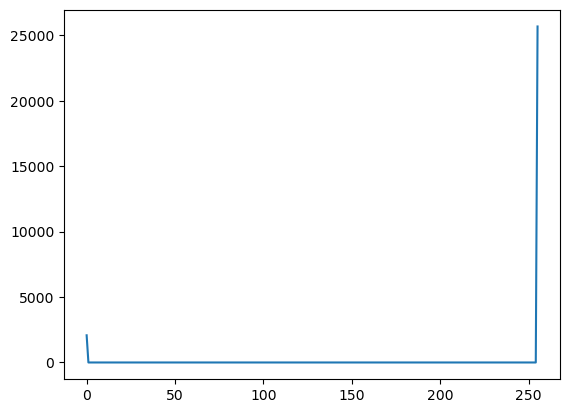

In [209]:
# Aplique el algoritmo de umbralización de Otsu sobre la imagen original y las dos modificaciones

# ---------- Umbralizacion con OTSU a la imagen original --------
thres_value, thres_image = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
print(thres_value)

# Visualizar imagen
plt.imshow(thres_image, cmap="gray",  vmin=0, vmax=255)
plt.show()

# Visualizar histograma
hist = cv2.calcHist([thres_image],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

# ---------- Umbralizacion con OTSU a la primera modificacion --------
thres_value, thres_image = cv2.threshold(spot_image, 0, 255, cv2.THRESH_OTSU)
print(thres_value)

# Visualizar imagen
plt.imshow(thres_image, cmap="gray",  vmin=0, vmax=255)
plt.show()

# Visualizar histograma
hist = cv2.calcHist([thres_image],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

# ---------- Umbralizacion con OTSU a la segunda modificacion --------
thres_value, thres_image = cv2.threshold(sinusoidal_image, 55, 255, cv2.THRESH_BINARY)
print(thres_value)

# Visualizar imagen
plt.imshow(thres_image, cmap="gray",  vmin=0, vmax=255)
plt.show()

# Visualizar histograma
hist = cv2.calcHist([thres_image],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

¿Qué sucede? ¿Por qué sucede esto? ¿Qué alternativas puede emplear para mitigar este resultado?

Sucede que esas sombras empiezan a interferir en la segmentación. Al establecer un umbral, hay pixeles de esas sombras que tienen valores muy cercanos a los de la region de interes y al tener la imagen binaria se distorsiona el resultado esperado. Lo que se me ocurre es empiricamente bajar el umbral, pero se pierden muchos pixeles por lo tanto nos alejamos de nuestro resultado esperado.

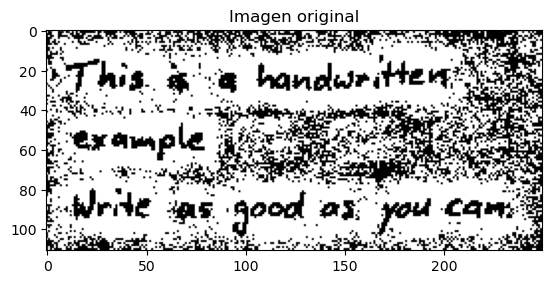

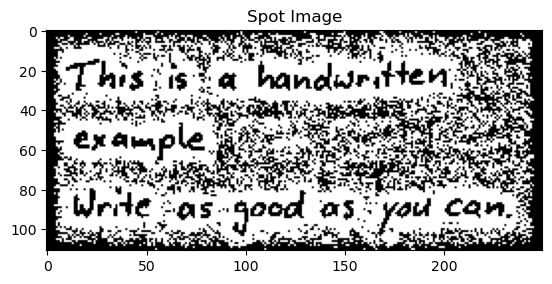

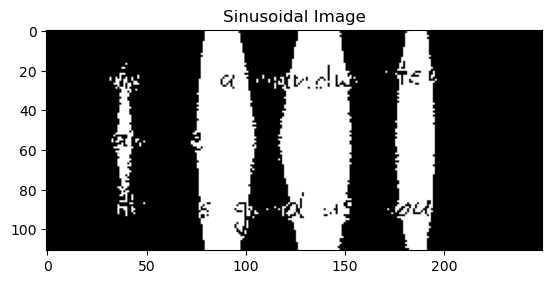

In [210]:
# Aplique ahora un algoritmo de adaptacion del umbral en función de las propiedades locales.
# Compare sus resultados con el algoritmo anterior, usando varios valores para el vecindario local

from skimage.filters import threshold_local

# ---- Imagen original ------
ti = threshold_local(image, block_size=25, method='mean')
binary_image = image > ti
thresholded_image = binary_image*255

# Visualizar imagen
plt.imshow(thresholded_image, cmap="gray",  vmin=0, vmax=255)
plt.title("Imagen original")
plt.show()

# ---- Primera modificacion ------
ti = threshold_local(spot_image, block_size=15, method='mean')
binary_image = spot_image > ti
thresholded_image = binary_image*255

# Visualizar imagen
plt.imshow(thresholded_image, cmap="gray",  vmin=0, vmax=255)
plt.title("Spot Image")
plt.show()

# ---- Segunda modificacion ------
ti = threshold_local(sinusoidal_image, block_size=3, method='mean')
binary_image = spot_image > ti
thresholded_image = binary_image*255

# Visualizar imagen
plt.imshow(thresholded_image, cmap="gray",  vmin=0, vmax=255)
plt.title("Sinusoidal Image")
plt.show()





¿En qué cambia el resultado con relación al método de Otsu? ¿Qué implicaciones tiene esto? ¿Cómo puede mejorar el resultado de la segmentación para reducir el ruido en ambos casos?

Lo que cambia es que con OTSU se esta utilizando umbralizacion global, al aplicar el local, se está aplicando un umbral diferente a cada pixel. Este umbral se define en base al promedio de los vecinos. Entonces al tener un umbral que no es global, se puede combatir contra este ruido para definir con mas precision estas segmentaciones.